In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state",
    "party",
    "barely_true",
    "false",
    "half_true",
    "mostly_true",
    "pants_fire",
    "context"
]

In [3]:
train = pd.read_csv(
    "../dataset/liar/train.tsv",
    sep="\t",
    header=None,
    names=columns
)

valid = pd.read_csv(
    "../dataset/liar/valid.tsv",
    sep="\t",
    header=None,
    names=columns
)

test = pd.read_csv(
    "../dataset/liar/test.tsv",
    sep="\t",
    header=None,
    names=columns
)

In [4]:
print("Train shape:", train.shape)
print("Validation shape:", valid.shape)
print("Test shape:", test.shape)

Train shape: (10240, 14)
Validation shape: (1284, 14)
Test shape: (1267, 14)


In [5]:
train.head()

,id,label,statement,subject,speaker,speaker_job,state,party,barely_true,false,half_true,mostly_true,pants_fire,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10240 non-null  str    
 1   label        10240 non-null  str    
 2   statement    10240 non-null  str    
 3   subject      10238 non-null  str    
 4   speaker      10238 non-null  str    
 5   speaker_job  7342 non-null   str    
 6   state        8030 non-null   str    
 7   party        10238 non-null  str    
 8   barely_true  10238 non-null  float64
 9   false        10238 non-null  float64
 10  half_true    10238 non-null  float64
 11  mostly_true  10238 non-null  float64
 12  pants_fire   10238 non-null  float64
 13  context      10138 non-null  str    
dtypes: float64(5), str(9)
memory usage: 1.1 MB


In [7]:
train["label"].value_counts()

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

In [8]:
print("Train:", len(train))
print("Validation:", len(valid))
print("Test:", len(test))

print("\nLabel distribution:")
print(train["label"].value_counts())

Train: 10240
Validation: 1284
Test: 1267

Label distribution:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


In [9]:
train["label"].value_counts(normalize=True) * 100

label
half-true      20.644531
false          19.482422
mostly-true    19.160156
true           16.367188
barely-true    16.152344
pants-fire      8.193359
Name: proportion, dtype: float64

In [11]:
train["statement"].isnull().sum()
train["label"].isnull().sum()

np.int64(0)

In [12]:
train["statement"].duplicated().sum()

np.int64(17)

In [13]:
valid["statement"].duplicated().sum()

np.int64(0)

In [15]:
train["statement_length"] = train["statement"].astype(str).str.len()

In [16]:
train["statement_length"].describe()

count    10240.000000
mean       106.918750
std         59.917722
min         11.000000
25%         73.000000
50%         99.000000
75%        132.250000
max       3192.000000
Name: statement_length, dtype: float64

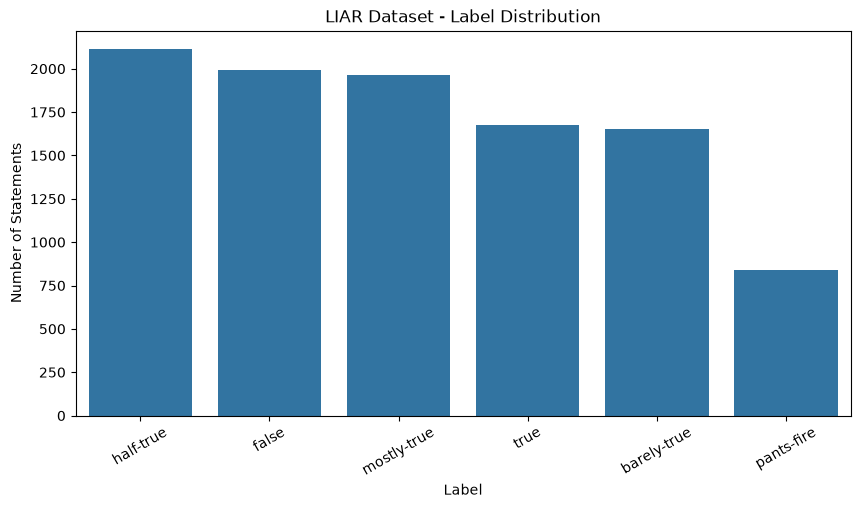

In [17]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train,
    x="label",
    order=train["label"].value_counts().index
)

plt.title("LIAR Dataset - Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Statements")
plt.xticks(rotation=30)

plt.show()

In [18]:
train.groupby("label")["statement_length"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
label,,,,,
barely-true,1654,108.34,100.0,20,391
false,1995,101.54,92.0,11,2099
half-true,2114,111.45,105.0,11,320
mostly-true,1962,109.01,100.0,19,3192
pants-fire,839,102.33,96.0,16,272
true,1676,106.05,98.0,11,1592


In [19]:
print("TRAIN")
print(train.isnull().sum())

print("\nVALIDATION")
print(valid.isnull().sum())

print("\nTEST")
print(test.isnull().sum())

TRAIN
id                     0
label                  0
statement              0
subject                2
speaker                2
speaker_job         2898
state               2210
party                  2
barely_true            2
false                  2
half_true              2
mostly_true            2
pants_fire             2
context              102
statement_length       0
dtype: int64

VALIDATION
id               0
label            0
statement        0
subject          0
speaker          0
speaker_job    345
state          279
party            0
barely_true      0
false            0
half_true        0
mostly_true      0
pants_fire       0
context         12
dtype: int64

TEST
id               0
label            0
statement        0
subject          0
speaker          0
speaker_job    325
state          262
party            0
barely_true      0
false            0
half_true        0
mostly_true      0
pants_fire       0
context         17
dtype: int64


In [20]:
for name, df in [
    ("TRAIN", train),
    ("VALIDATION", valid),
    ("TEST", test)
]:
    print(f"\n{name}")
    missing = df.isnull().sum()
    print(missing[missing > 0])


TRAIN
subject           2
speaker           2
speaker_job    2898
state          2210
party             2
barely_true       2
false             2
half_true         2
mostly_true       2
pants_fire        2
context         102
dtype: int64

VALIDATION
speaker_job    345
state          279
context         12
dtype: int64

TEST
speaker_job    325
state          262
context         17
dtype: int64


In [21]:
duplicates = train[
    train["statement"].duplicated(keep=False)
].sort_values("statement")

duplicates[["statement", "label"]]

,statement,label
4839,During Sherrod Browns past decade as a D.C. po...,half-true
1582,During Sherrod Browns past decade as a D.C. po...,half-true
1526,"Four balanced budgets in a row, with no new ta...",half-true
2846,"Four balanced budgets in a row, with no new ta...",mostly-true
848,"Obama says Iran is a 'tiny' country, 'doesn't ...",false
1846,"Obama says Iran is a 'tiny' country, 'doesn't ...",false
3256,On a cap-and-trade plan.,false
2872,On a cap-and-trade plan.,false
709,On abortion,false
1014,On abortion,half-true


In [22]:
label_distribution = (
    train["label"]
    .value_counts()
    .to_frame("count")
)

label_distribution["percentage"] = (
    label_distribution["count"] / len(train) * 100
).round(2)

label_distribution

,count,percentage
label,,
half-true,2114,20.64
false,1995,19.48
mostly-true,1962,19.16
true,1676,16.37
barely-true,1654,16.15
pants-fire,839,8.19


## EDA Findings

- The LIAR dataset contains 10,240 training samples, 1,284 validation samples, and 1,267 test samples.
- The dataset contains six truthfulness labels: `true`, `mostly-true`, `half-true`, `barely-true`, `false`, and `pants-fire`.
- The training set is moderately imbalanced. The `pants-fire` class is the smallest class with approximately 8.2% of the training data, while `half-true` is the largest with approximately 20.6%.
- No missing values were found in the `statement` or `label` columns, which are the primary columns required for our classification task.
- Missing values are mainly present in metadata fields such as `speaker_job`, `state`, and `context`. These fields will not be used in the initial TF-IDF baseline.
- Most statements are relatively short. The median statement length is 99 characters and the mean is approximately 107 characters. However, a small number of substantially longer statements are also present.
- Statement length does not show a large difference across the six truthfulness categories.
- A small number of duplicate statements exist. Some duplicates have different labels, indicating that the surrounding context or metadata may be important. Therefore, duplicate statements will not be blindly removed based only on the statement text.